# Credit and Liquidity Stress Model Backtest

This notebook:

1. pulls **credit stress** from FRED,
2. pulls **liquidity stress** from the New York Fed using your `NYFedClient`,
3. builds a **latent stress score** and **stress probability**,
4. backtests whether elevated stress predicts bad forward outcomes in **BKLN**, **HYG**, and **SPY**,
5. optionally fits a **PyMC latent factor model** for comparison.

Set your environment variables before running:

- `FRED_API_KEY`
- `NYFED_BASE_URL` (optional, defaults to `https://markets.newyorkfed.org/api`)

In [1]:
# Make the project root (the parent of 'notebooks/') importable
import sys, pathlib
cwd = pathlib.Path.cwd()
if cwd.name == "notebooks":
    proj_root = cwd.parent
else:
    proj_root = cwd  # if you launched from project root
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

In [2]:
from dotenv import find_dotenv, load_dotenv

In [3]:
load_dotenv(find_dotenv())

True

In [6]:
from __future__ import annotations

import datetime as dt
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pymc as pm
import arviz as az

from scipy.special import expit
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

from fredapi import Fred
from nyfed_client import NYFedClient, FetchSpec


/Users/mozilla/Library/Caches/pypoetry/virtualenvs/credit-liquidity-monitor-Wwjgk1LW-py3.12/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  from .wrappers import *


In [7]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
NYFED_BASE_URL = os.environ.get("NYFED_BASE_URL", "https://markets.newyorkfed.org/api")

START_DATE = dt.date(2007, 1, 1)
END_DATE = dt.date.today()

ROLLING_WINDOW = 60
FORWARD_DAYS = 20  # about 1 trading month

if not FRED_API_KEY:
    print("Warning: FRED_API_KEY is not set.")

In [8]:
fred = Fred(api_key=FRED_API_KEY) if FRED_API_KEY else None

def fetch_fred_series(series_id: str, start_date: dt.date, end_date: dt.date) -> pd.Series:
    s = fred.get_series(
        series_id,
        observation_start=start_date,
        observation_end=end_date,
    )
    if s is None or len(s) == 0:
        return pd.Series(dtype=float, name=series_id)

    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s.name = series_id
    return s

def fetch_nyfed_series(
    client: NYFedClient,
    dataset: str,
    key: str,
    start_date: dt.date,
    end_date: dt.date,
) -> pd.Series:
    rows = client.fetch_series(
        FetchSpec(dataset=dataset, key=key),
        start_date=start_date,
        end_date=end_date,
    )
    if not rows:
        return pd.Series(dtype=float, name=key)

    df = pd.DataFrame(rows, columns=["date", "value"])
    df["date"] = pd.to_datetime(df["date"])
    s = df.set_index("date")["value"].astype(float).sort_index()
    s.name = key
    return s

def rolling_zscore(s: pd.Series, window: int = 60) -> pd.Series:
    mu = s.rolling(window).mean()
    sd = s.rolling(window).std(ddof=0)
    z = (s - mu) / sd.replace(0.0, np.nan)
    return z

def max_drawdown_forward(price: pd.Series, horizon: int) -> pd.Series:
    out = pd.Series(index=price.index, dtype=float)
    vals = price.values
    idx = price.index
    for i in range(len(price) - horizon):
        window = vals[i+1:i+1+horizon]
        if len(window) == 0:
            continue
        out.loc[idx[i]] = window.min() / vals[i] - 1.0
    return out

def forward_return(price: pd.Series, horizon: int) -> pd.Series:
    return price.shift(-horizon) / price - 1.0

## Pull stress data

In [9]:
nyfed = NYFedClient(base_url=NYFED_BASE_URL)

# FRED credit series
hy_oas = fetch_fred_series("BAMLH0A0HYM2", START_DATE, END_DATE)      # HY OAS
bbb_oas = fetch_fred_series("BAMLC0A4CBBB", START_DATE, END_DATE)     # BBB OAS

# NY Fed liquidity series
sofr = fetch_nyfed_series(nyfed, "reference_rates", "SOFR", START_DATE, END_DATE)
effr = fetch_nyfed_series(nyfed, "reference_rates", "EFFR", START_DATE, END_DATE)
rrp_total = fetch_nyfed_series(nyfed, "repo_reverse_repo", "RRP_TOTAL", START_DATE, END_DATE)
repo_total = fetch_nyfed_series(nyfed, "repo_reverse_repo", "REPO_TOTAL", START_DATE, END_DATE)

print("HY OAS:", hy_oas.dropna().index.min(), hy_oas.dropna().index.max(), len(hy_oas))
print("BBB OAS:", bbb_oas.dropna().index.min(), bbb_oas.dropna().index.max(), len(bbb_oas))
print("SOFR:", sofr.dropna().index.min() if len(sofr.dropna()) else None, sofr.dropna().index.max() if len(sofr.dropna()) else None, len(sofr))
print("EFFR:", effr.dropna().index.min() if len(effr.dropna()) else None, effr.dropna().index.max() if len(effr.dropna()) else None, len(effr))
print("RRP:", rrp_total.dropna().index.min() if len(rrp_total.dropna()) else None, rrp_total.dropna().index.max() if len(rrp_total.dropna()) else None, len(rrp_total))
print("Repo:", repo_total.dropna().index.min() if len(repo_total.dropna()) else None, repo_total.dropna().index.max() if len(repo_total.dropna()) else None, len(repo_total))

HY OAS: 2007-01-02 00:00:00 2026-03-17 00:00:00 5017
BBB OAS: 2007-01-02 00:00:00 2026-03-17 00:00:00 5017
SOFR: 2018-04-02 00:00:00 2026-03-17 00:00:00 1987
EFFR: 2007-01-02 00:00:00 2026-03-17 00:00:00 4824
RRP: 2026-03-04 00:00:00 2026-03-18 00:00:00 11
Repo: 2026-03-04 00:00:00 2026-03-18 00:00:00 11


In [10]:
df = pd.concat(
    [
        hy_oas.rename("hy_oas"),
        bbb_oas.rename("bbb_oas"),
        sofr.rename("sofr"),
        effr.rename("effr"),
        rrp_total.rename("rrp_total"),
        repo_total.rename("repo_total"),
    ],
    axis=1,
).sort_index()

df["sofr"] = df["sofr"].ffill()
df["effr"] = df["effr"].ffill()

df["sofr_effr_spread_bps"] = (df["sofr"] - df["effr"]) * 100.0
df["hy_minus_bbb"] = df["hy_oas"] - df["bbb_oas"]

for col in ["hy_oas", "bbb_oas", "hy_minus_bbb", "sofr_effr_spread_bps", "rrp_total", "repo_total"]:
    df[f"{col}_z"] = rolling_zscore(df[col], ROLLING_WINDOW)

df.tail()

/var/folders/nf/0f78fmr95hz6c9cwnjjzzdlr0000gp/T/ipykernel_58588/3844253961.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat(


,hy_oas,bbb_oas,sofr,effr,rrp_total,repo_total,sofr_effr_spread_bps,hy_minus_bbb,hy_oas_z,bbb_oas_z,hy_minus_bbb_z,sofr_effr_spread_bps_z,rrp_total_z,repo_total_z
2026-03-12,3.17,1.12,3.65,3.64,137000000.0,6000000.0,1.0,2.05,2.239939,2.822865,1.754754,-0.511020,NaN,NaN
2026-03-13,3.28,1.15,3.65,3.64,427000000.0,0.0,1.0,2.13,2.805057,3.161008,2.381170,-0.506019,NaN,NaN
2026-03-16,3.27,1.16,3.70,3.64,582000000.0,0.0,6.0,2.11,2.539367,3.052810,2.074412,0.737174,NaN,NaN
2026-03-17,3.22,1.14,3.65,3.64,797000000.0,0.0,1.0,2.08,2.089799,2.485990,1.723111,-0.507295,NaN,NaN
2026-03-18,NaN,NaN,3.65,3.64,698000000.0,6000000.0,1.0,NaN,NaN,NaN,NaN,-0.502343,NaN,NaN


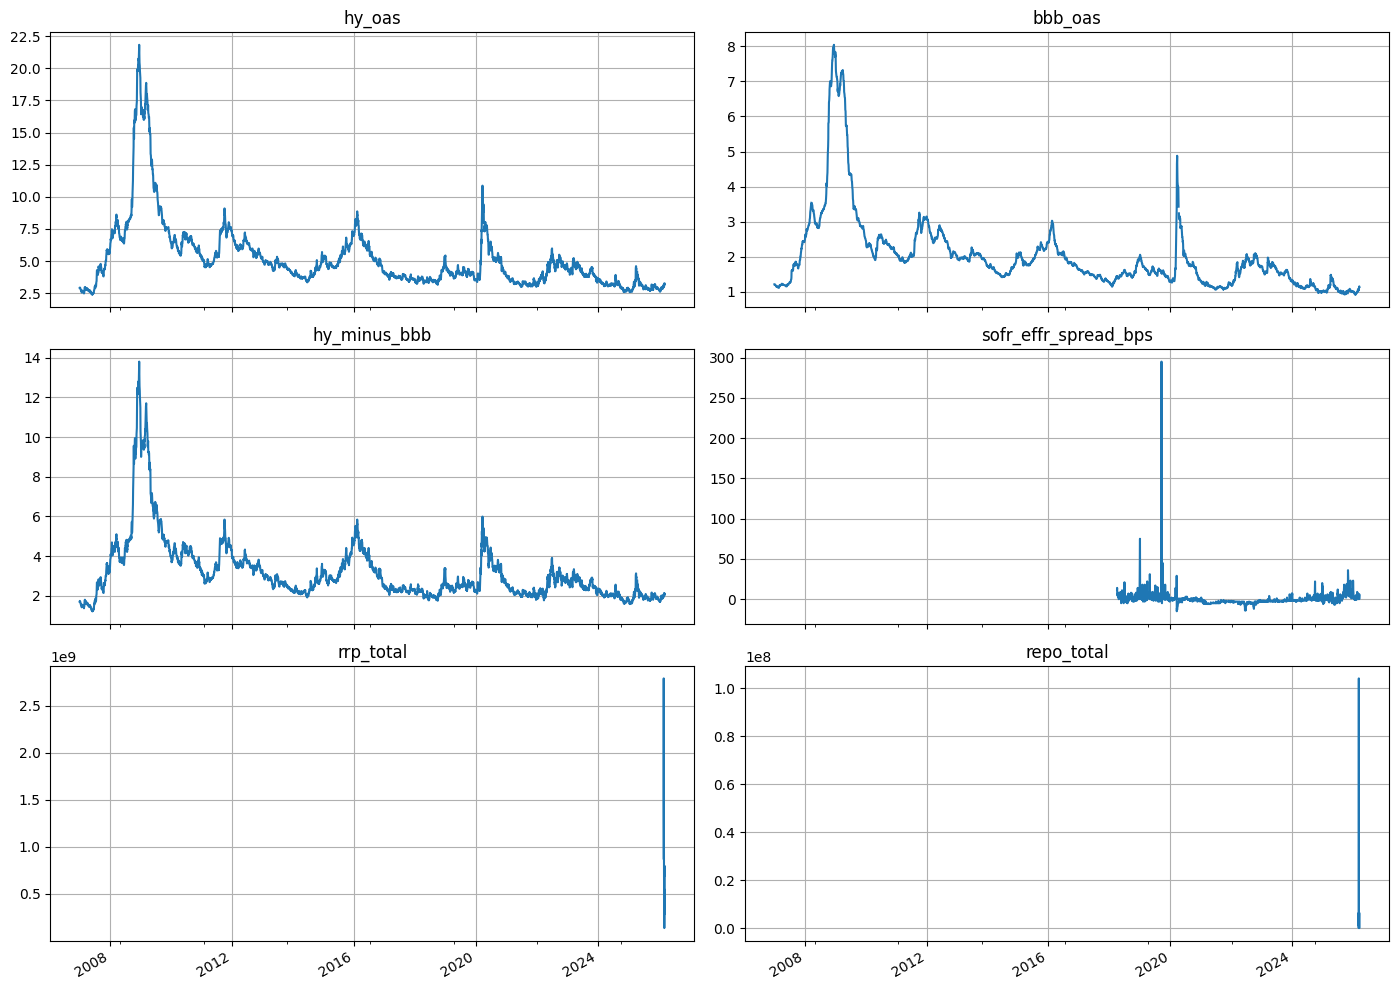

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

plot_cols = [
    "hy_oas",
    "bbb_oas",
    "hy_minus_bbb",
    "sofr_effr_spread_bps",
    "rrp_total",
    "repo_total",
]

for ax, col in zip(axes.ravel(), plot_cols):
    df[col].plot(ax=ax, title=col)

plt.tight_layout()
plt.show()

## Fast latent stress model

This is the production-friendly version: a weighted factor score plus smoothing.

In [12]:
weights = {
    "hy_oas_z": 0.30,
    "bbb_oas_z": 0.15,
    "hy_minus_bbb_z": 0.20,
    "sofr_effr_spread_bps_z": 0.20,
    "rrp_total_z": 0.10,
    "repo_total_z": 0.05,
}

usable = [c for c in weights if c in df.columns]
X = df[usable].copy()
X = X.replace([np.inf, -np.inf], np.nan).ffill()

w = np.array([weights[c] for c in usable], dtype=float)
w = w / w.sum()

df["latent_stress_raw"] = X.mul(w, axis=1).sum(axis=1)
df["latent_stress"] = df["latent_stress_raw"].ewm(span=5, adjust=False).mean()
df["stress_prob"] = expit(df["latent_stress"])

df[["latent_stress", "stress_prob"]].tail()

,latent_stress,stress_prob
2026-03-12,1.147546,0.759062
2026-03-13,1.328597,0.790608
2026-03-16,1.479748,0.814534
2026-03-17,1.400832,0.802316
2026-03-18,1.348552,0.793893


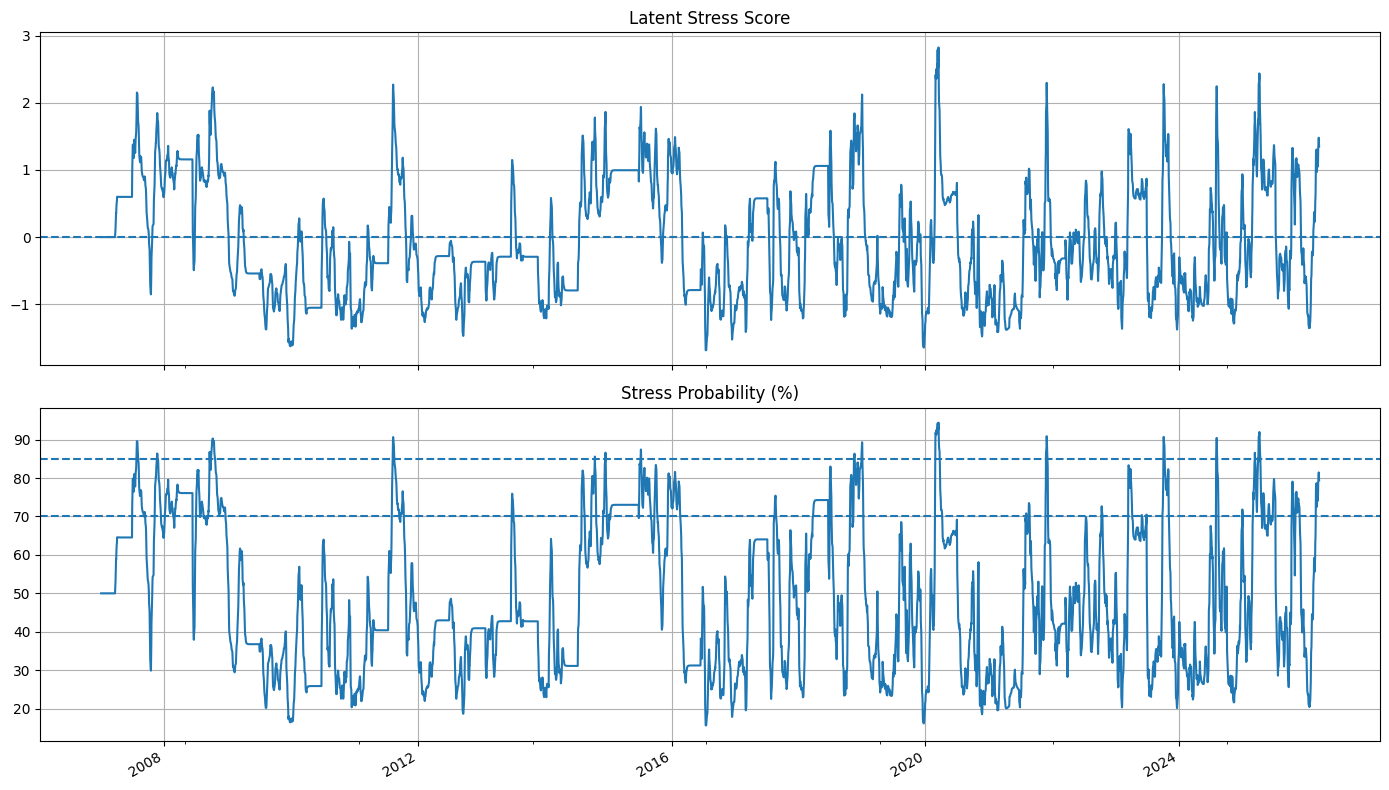

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df["latent_stress"].plot(ax=axes[0], title="Latent Stress Score")
axes[0].axhline(0.0, linestyle="--")

(df["stress_prob"] * 100).plot(ax=axes[1], title="Stress Probability (%)")
axes[1].axhline(70, linestyle="--")
axes[1].axhline(85, linestyle="--")

plt.tight_layout()
plt.show()

## Market proxies for validation

In [14]:
prices = yf.download(
    ["BKLN", "HYG", "SPY"],
    start=str(START_DATE),
    end=str(END_DATE + dt.timedelta(days=1)),
    auto_adjust=True,
    progress=False,
)["Close"]

prices = prices.dropna(how="all")
prices.tail()

Ticker,BKLN,HYG,SPY
Date,,,
2026-03-12,20.500000,79.349998,666.059998
2026-03-13,20.459999,79.199997,662.289978
2026-03-16,20.469999,79.449997,669.030029
2026-03-17,20.540001,79.809998,670.789978
2026-03-18,20.530001,79.400002,661.429993


In [15]:
bt = df.join(prices, how="inner")

for ticker in ["BKLN", "HYG", "SPY"]:
    bt[f"{ticker}_fwd_ret_{FORWARD_DAYS}d"] = forward_return(bt[ticker], FORWARD_DAYS)
    bt[f"{ticker}_fwd_mdd_{FORWARD_DAYS}d"] = max_drawdown_forward(bt[ticker], FORWARD_DAYS)

bt["bad_bkln"] = (bt[f"BKLN_fwd_ret_{FORWARD_DAYS}d"] <= -0.02).astype(float)
bt["bad_hyg"] = (bt[f"HYG_fwd_ret_{FORWARD_DAYS}d"] <= -0.025).astype(float)
bt["bad_spy"] = (bt[f"SPY_fwd_ret_{FORWARD_DAYS}d"] <= -0.05).astype(float)

bt[[f"BKLN_fwd_ret_{FORWARD_DAYS}d", "bad_bkln", "stress_prob"]].dropna().tail()

,BKLN_fwd_ret_20d,bad_bkln,stress_prob
2026-02-11,-0.003829,0.0,0.442003
2026-02-12,-0.002880,0.0,0.478230
2026-02-13,-0.003359,0.0,0.523722
2026-02-17,-0.000436,0.0,0.592055
2026-02-18,-0.001889,0.0,0.583589


In [16]:
def decile_analysis(df_in: pd.DataFrame, score_col: str, target_col: str, n=10):
    x = df_in[[score_col, target_col]].dropna().copy()
    x["bucket"] = pd.qcut(x[score_col], n, duplicates="drop")
    out = x.groupby("bucket")[target_col].agg(["mean", "count"])
    return out

print("BKLN bad-outcome rate by stress decile")
display(decile_analysis(bt, "stress_prob", "bad_bkln"))

print("HYG bad-outcome rate by stress decile")
display(decile_analysis(bt, "stress_prob", "bad_hyg"))

print("SPY bad-outcome rate by stress decile")
display(decile_analysis(bt, "stress_prob", "bad_spy"))

BKLN bad-outcome rate by stress decile


,mean,count
bucket,,
"(0.156, 0.256]",0.000000,484
"(0.256, 0.298]",0.006211,483
"(0.298, 0.339]",0.004141,483
"(0.339, 0.397]",0.010352,483
"(0.397, 0.428]",0.047619,483
"(0.428, 0.5]",0.060362,497
"(0.5, 0.622]",0.061834,469
"(0.622, 0.694]",0.018634,483
"(0.694, 0.753]",0.010352,483


HYG bad-outcome rate by stress decile


,mean,count
bucket,,
"(0.156, 0.256]",0.033058,484
"(0.256, 0.298]",0.043478,483
"(0.298, 0.339]",0.043478,483
"(0.339, 0.397]",0.082816,483
"(0.397, 0.428]",0.120083,483
"(0.428, 0.5]",0.102616,497
"(0.5, 0.622]",0.117271,469
"(0.622, 0.694]",0.062112,483
"(0.694, 0.753]",0.089027,483


SPY bad-outcome rate by stress decile


,mean,count
bucket,,
"(0.156, 0.256]",0.035124,484
"(0.256, 0.298]",0.084886,483
"(0.298, 0.339]",0.041408,483
"(0.339, 0.397]",0.093168,483
"(0.397, 0.428]",0.082816,483
"(0.428, 0.5]",0.104628,497
"(0.5, 0.622]",0.095949,469
"(0.622, 0.694]",0.062112,483
"(0.694, 0.753]",0.072464,483


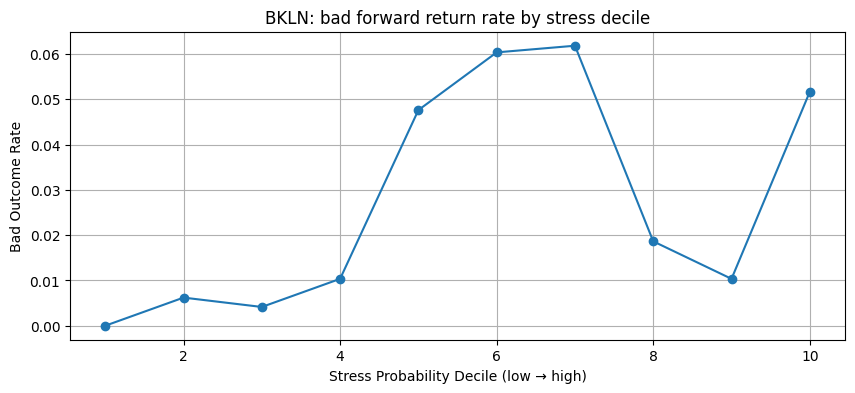

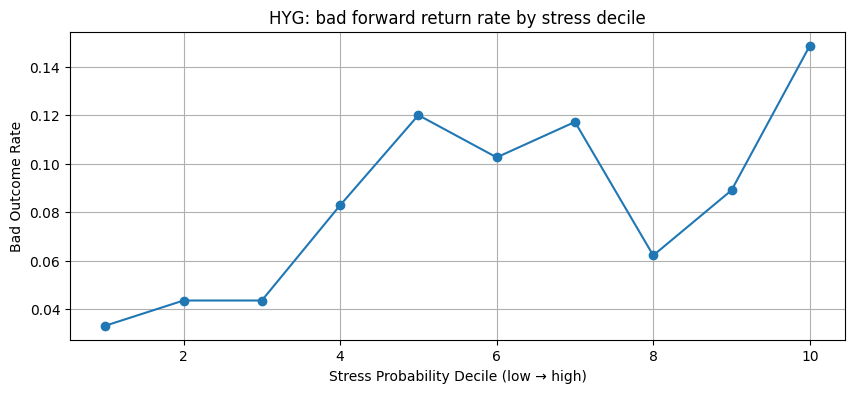

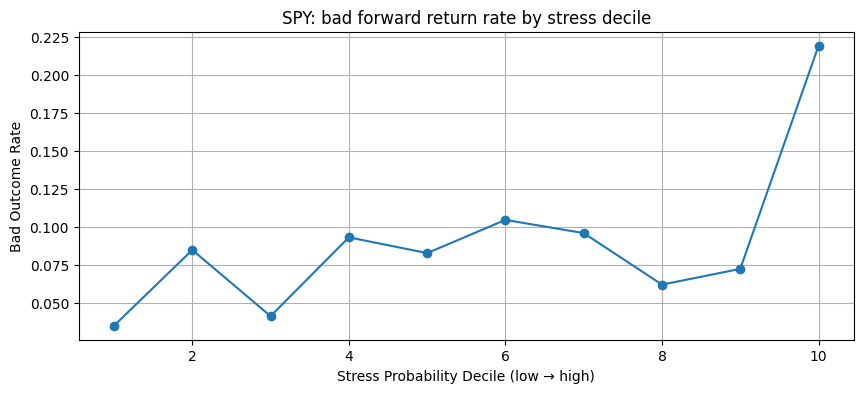

In [17]:
def plot_decile_curve(df_in: pd.DataFrame, score_col: str, target_col: str, title: str):
    x = df_in[[score_col, target_col]].dropna().copy()
    x["bucket"] = pd.qcut(x[score_col], 10, duplicates="drop")
    out = x.groupby("bucket")[target_col].mean().reset_index()
    out["bucket_num"] = np.arange(1, len(out) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(out["bucket_num"], out[target_col], marker="o")
    plt.title(title)
    plt.xlabel("Stress Probability Decile (low → high)")
    plt.ylabel("Bad Outcome Rate")
    plt.show()

plot_decile_curve(bt, "stress_prob", "bad_bkln", "BKLN: bad forward return rate by stress decile")
plot_decile_curve(bt, "stress_prob", "bad_hyg", "HYG: bad forward return rate by stress decile")
plot_decile_curve(bt, "stress_prob", "bad_spy", "SPY: bad forward return rate by stress decile")

In [18]:
def score_classifier(df_in: pd.DataFrame, prob_col: str, target_col: str, threshold: float = 0.70):
    x = df_in[[prob_col, target_col]].dropna().copy()
    y_true = x[target_col].astype(int).values
    y_prob = x[prob_col].values
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    return pd.Series({
        "auc": auc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "threshold": threshold,
        "base_rate": y_true.mean(),
    })

results = pd.DataFrame({
    "BKLN": score_classifier(bt, "stress_prob", "bad_bkln"),
    "HYG": score_classifier(bt, "stress_prob", "bad_hyg"),
    "SPY": score_classifier(bt, "stress_prob", "bad_spy"),
}).T

results

,auc,precision,recall,f1,threshold,base_rate
BKLN,0.641059,0.032293,0.229008,0.056604,0.7,0.027111
HYG,0.595756,0.113025,0.257985,0.157186,0.7,0.084230
SPY,0.599905,0.143165,0.308585,0.195588,0.7,0.089197


## Event study around high-stress dates

In [19]:
stress_dates = bt.index[bt["stress_prob"] >= 0.85]

selected = []
last = None
for d in stress_dates:
    if last is None or (d - last).days >= 28:
        selected.append(d)
        last = d

selected[:20], len(selected)

([Timestamp('2007-07-25 00:00:00'),
  Timestamp('2007-11-20 00:00:00'),
  Timestamp('2008-09-18 00:00:00'),
  Timestamp('2008-10-16 00:00:00'),
  Timestamp('2011-08-09 00:00:00'),
  Timestamp('2014-10-15 00:00:00'),
  Timestamp('2014-12-15 00:00:00'),
  Timestamp('2015-07-06 00:00:00'),
  Timestamp('2018-11-16 00:00:00'),
  Timestamp('2018-12-31 00:00:00'),
  Timestamp('2020-02-28 00:00:00'),
  Timestamp('2021-11-26 00:00:00'),
  Timestamp('2023-10-03 00:00:00'),
  Timestamp('2024-08-02 00:00:00'),
  Timestamp('2025-03-13 00:00:00'),
  Timestamp('2025-04-10 00:00:00')],
 16)

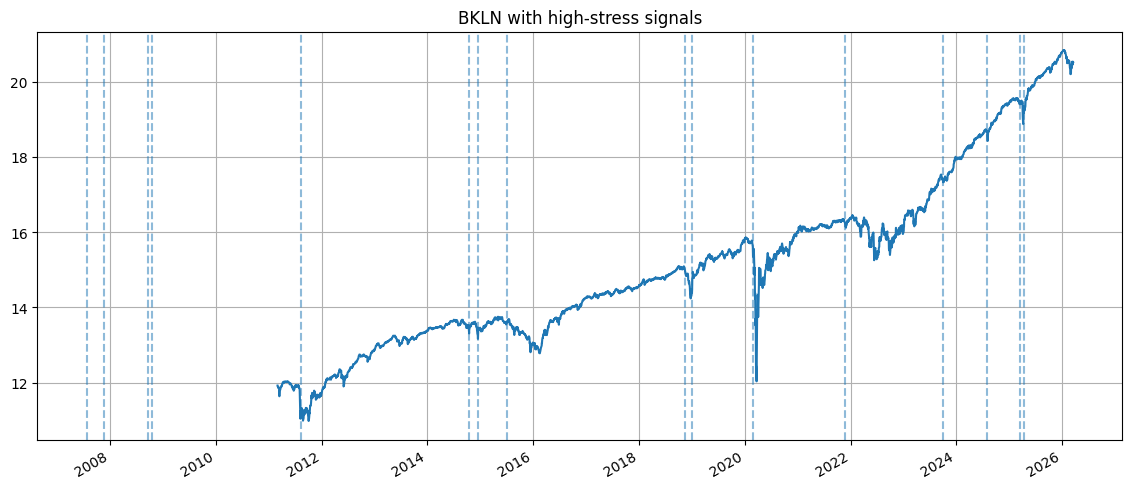

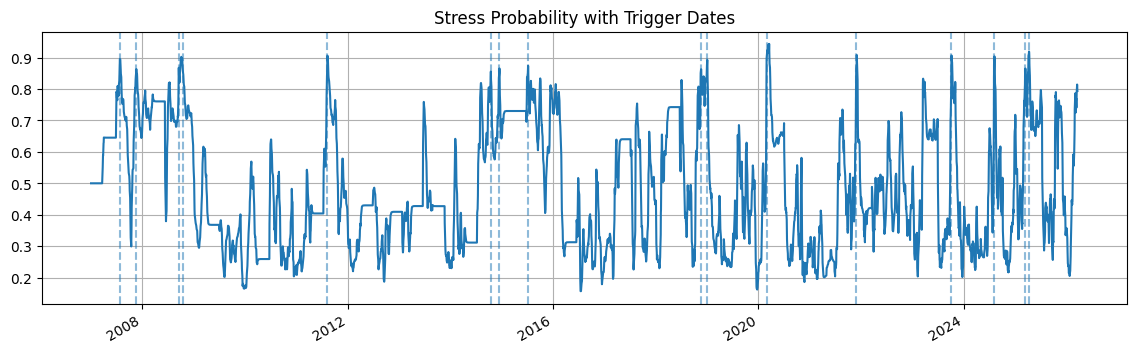

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 6))

bt["BKLN"].plot(ax=ax1)
ax1.set_title("BKLN with high-stress signals")

for d in selected:
    ax1.axvline(d, linestyle="--", alpha=0.5)

plt.show()

plt.figure(figsize=(14, 4))
bt["stress_prob"].plot()
for d in selected:
    plt.axvline(d, linestyle="--", alpha=0.5)
plt.title("Stress Probability with Trigger Dates")
plt.show()

## Optional PyMC latent model

This is slower, but it gives you a true Bayesian latent time-series factor model.

In [31]:
feature_cols = [
    "hy_oas_z",
    "bbb_oas_z",
    "hy_minus_bbb_z",
    "sofr_effr_spread_bps_z",
]

pymc_df = df[feature_cols].copy()
pymc_df = pymc_df.replace([np.inf, -np.inf], np.nan)
pymc_df = pymc_df.ffill()
pymc_df = pymc_df.dropna()

print("pymc_df shape:", pymc_df.shape)

if len(pymc_df) < 20:
    raise ValueError(f"Not enough rows for PyMC model: {len(pymc_df)}")

X_df = pymc_df.copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna()
X_df = (X_df - X_df.mean()) / X_df.std(ddof=0)

X = np.asarray(X_df.to_numpy(), dtype="float64", order="C")
n, k = X.shape

with pm.Model(coords={"time": np.arange(n), "feature": X_df.columns}) as latent_model:
    sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.3)

    S = pm.GaussianRandomWalk(
        "S",
        sigma=sigma_rw,
        init_dist=pm.Normal.dist(0.0, 1.0),
        steps=n - 1,
        dims="time",
    )

    alpha = pm.Normal("alpha", mu=0.0, sigma=0.5, dims="feature")
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="feature")
    sigma = pm.HalfNormal("sigma", sigma=0.5, dims="feature")

    mu = pm.Deterministic(
        "mu",
        alpha[None, :] + beta[None, :] * S[:, None],
        dims=("time", "feature"),
    )

    nu = pm.Exponential("nu", 1 / 10) + 2
    y = pm.StudentT(
        "y",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=X,
        dims=("time", "feature"),
    )

    trace = pm.sample(
        draws=1000,
        tune=2500,
        chains=2,
        target_accept=0.95,
        random_seed=42,
        progressbar=True
    )

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3500    0             0.01        767          3.00 draws/s     0:19:25   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3500    0             0.05        511          4.28 draws/s     0:13:37   0:00:00

Sampling 2 chains for 2_500 tune and 1_000 draw iterations (5_000 + 2_000 draws total) took 1184 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [32]:
S_post = trace.posterior["S"].mean(dim=("chain", "draw")).values
pymc_df["pymc_latent_stress"] = S_post
pymc_df["pymc_stress_prob"] = expit(pymc_df["pymc_latent_stress"])

pymc_df[["pymc_latent_stress", "pymc_stress_prob"]].tail()

,pymc_latent_stress,pymc_stress_prob
2026-03-12,1.881255,0.867755
2026-03-13,2.300542,0.908922
2026-03-16,2.103822,0.891274
2026-03-17,1.770528,0.854523
2026-03-18,1.770273,0.854492


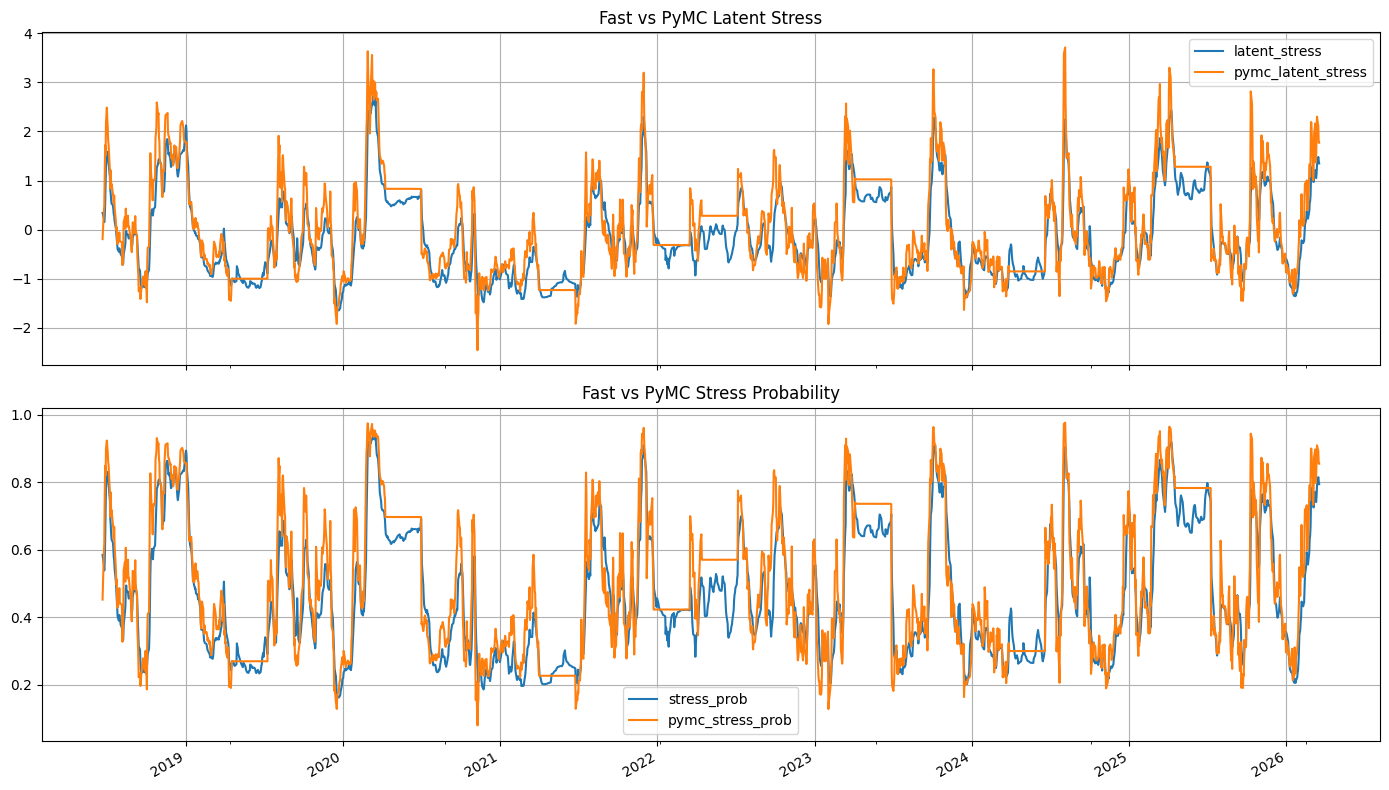

                    latent_stress  stress_prob  pymc_latent_stress  \
latent_stress            1.000000     0.995818            0.935994   
stress_prob              0.995818     1.000000            0.933837   
pymc_latent_stress       0.935994     0.933837            1.000000   
pymc_stress_prob         0.929622     0.936866            0.990322   

                    pymc_stress_prob  
latent_stress               0.929622  
stress_prob                 0.936866  
pymc_latent_stress          0.990322  
pymc_stress_prob            1.000000  


In [33]:
compare = df[["latent_stress", "stress_prob"]].join(
    pymc_df[["pymc_latent_stress", "pymc_stress_prob"]],
    how="inner"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

compare[["latent_stress", "pymc_latent_stress"]].plot(ax=axes[0], title="Fast vs PyMC Latent Stress")
compare[["stress_prob", "pymc_stress_prob"]].plot(ax=axes[1], title="Fast vs PyMC Stress Probability")

plt.tight_layout()
plt.show()

print(compare.corr())

In [34]:
bt2 = bt.join(
    pymc_df[["pymc_latent_stress", "pymc_stress_prob"]],
    how="inner"
)

pymc_results = pd.DataFrame({
    "BKLN": score_classifier(bt2, "pymc_stress_prob", "bad_bkln"),
    "HYG": score_classifier(bt2, "pymc_stress_prob", "bad_hyg"),
    "SPY": score_classifier(bt2, "pymc_stress_prob", "bad_spy"),
}).T

pymc_results

,auc,precision,recall,f1,threshold,base_rate
BKLN,0.715795,0.072261,0.326316,0.118321,0.7,0.048868
HYG,0.587961,0.044289,0.153226,0.068716,0.7,0.063786
SPY,0.572191,0.081585,0.196629,0.115321,0.7,0.091564


In [35]:
def threshold_sweep(df_in: pd.DataFrame, prob_col: str, target_col: str):
    rows = []
    x = df_in[[prob_col, target_col]].dropna()
    y_true = x[target_col].astype(int).values
    y_prob = x[prob_col].values

    for thresh in np.arange(0.50, 0.96, 0.05):
        y_pred = (y_prob >= thresh).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        rows.append({"threshold": thresh, "precision": p, "recall": r, "f1": f1})

    return pd.DataFrame(rows)

sweep = threshold_sweep(bt, "stress_prob", "bad_bkln")
sweep

,threshold,precision,recall,f1
0,0.50,0.034430,0.519084,0.064577
1,0.55,0.033353,0.435115,0.061957
2,0.60,0.027922,0.328244,0.051466
3,0.65,0.031329,0.282443,0.056402
4,0.70,0.032293,0.229008,0.056604
5,0.75,0.052953,0.198473,0.083601
6,0.80,0.082969,0.145038,0.105556
7,0.85,0.118280,0.083969,0.098214
8,0.90,0.269231,0.053435,0.089172
9,0.95,0.000000,0.000000,0.000000


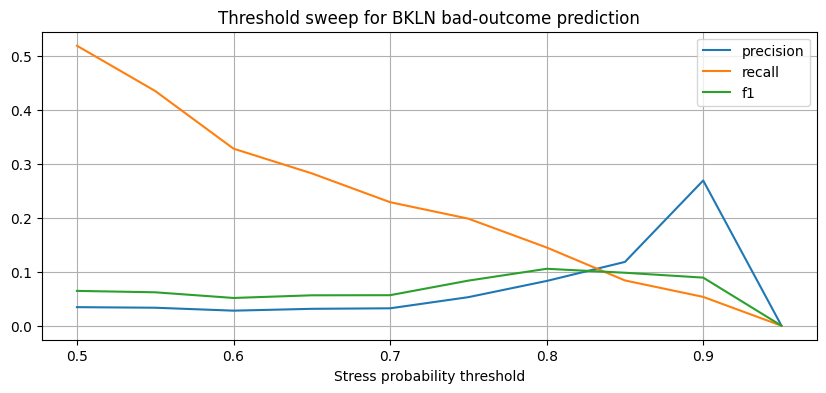

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(sweep["threshold"], sweep["precision"], label="precision")
plt.plot(sweep["threshold"], sweep["recall"], label="recall")
plt.plot(sweep["threshold"], sweep["f1"], label="f1")
plt.legend()
plt.title("Threshold sweep for BKLN bad-outcome prediction")
plt.xlabel("Stress probability threshold")
plt.show()

## Interpretation checklist

Things you want to see:

- higher **stress deciles** should map to worse forward returns or drawdowns,
- **AUC > 0.60** is useful,
- top stress periods should line up with real dislocations,
- the PyMC version should ideally be smoother or improve regime identification.

This is not directly testing private credit defaults. It is testing whether your stress engine anticipates deterioration in liquid proxy markets like **BKLN**, **HYG**, and **SPY**.